In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Pulling Sea Surface Temperature for Arabian Sea
# Using NOAA ERDDAP - completely free

url = (
    "https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdHadSST.csv?"
    "sst[(2020-01-01):1:(2024-12-31)][(15.0):1:(25.0)][(55.0):1:(75.0)]"
)

print("Pulling data from NOAA... this might take a minute")
df = pd.read_csv(url, skiprows=[1])
df.columns = ['time', 'latitude', 'longitude', 'sst']
df['time'] = pd.to_datetime(df['time'])
df = df.dropna()

print(f"Got {len(df)} data points")
print(df.head())

# Plot it
plt.figure(figsize=(12, 5))
plt.plot(df.groupby('time')['sst'].mean())
plt.title('Arabian Sea - Average Sea Surface Temperature (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/sst_arabian_sea.png')
plt.show()

print("Done! Check your outputs folder for the graph.")

Matplotlib is building the font cache; this may take a moment.


Pulling data from NOAA... this might take a minute


HTTPError: HTTP Error 404: 

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import io

# Using NOAA ERDDAP - updated working endpoint
url = (
    "https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdHadSST.csv?"
    "sst[(2020-01-01T00:00:00Z):1:(2023-12-01T00:00:00Z)]"
    "[(20.0):1:(20.0)][(65.0):1:(65.0)]"
)

print("Pulling data from NOAA...")

try:
    response = requests.get(url, timeout=60)
    print(f"Status code: {response.status_code}")
    
    if response.status_code == 200:
        df = pd.read_csv(io.StringIO(response.text), skiprows=[1])
        df.columns = ['time', 'latitude', 'longitude', 'sst']
        df['time'] = pd.to_datetime(df['time'])
        df = df.dropna()
        
        print(f"Got {len(df)} data points")
        print(df.head())
        
        plt.figure(figsize=(12, 5))
        plt.plot(df['time'], df['sst'], color='steelblue')
        plt.title('Arabian Sea - Sea Surface Temperature (2020-2023)')
        plt.xlabel('Date')
        plt.ylabel('Temperature (°C)')
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('../outputs/sst_arabian_sea.png')
        plt.show()
        print("Done! Graph saved.")
    else:
        print(f"Error from server: {response.text[:500]}")

except Exception as e:
    print(f"Something went wrong: {e}")

Pulling data from NOAA...
Status code: 404
Error from server: Error {
    code=404;
    message="Not Found: Currently unknown datasetID=erdHadSST";
}



Pulling data from NOAA (NASA MUR SST dataset)...
Status code: 200
Got 48 data points
                       time  latitude  longitude        sst
0 2020-01-16 00:00:00+00:00      20.0       65.0  24.594269
1 2020-02-16 00:00:00+00:00      20.0       65.0  24.463196
2 2020-03-16 00:00:00+00:00      20.0       65.0  25.671814
3 2020-04-16 00:00:00+00:00      20.0       65.0  28.379211
4 2020-05-16 00:00:00+00:00      20.0       65.0  29.858612


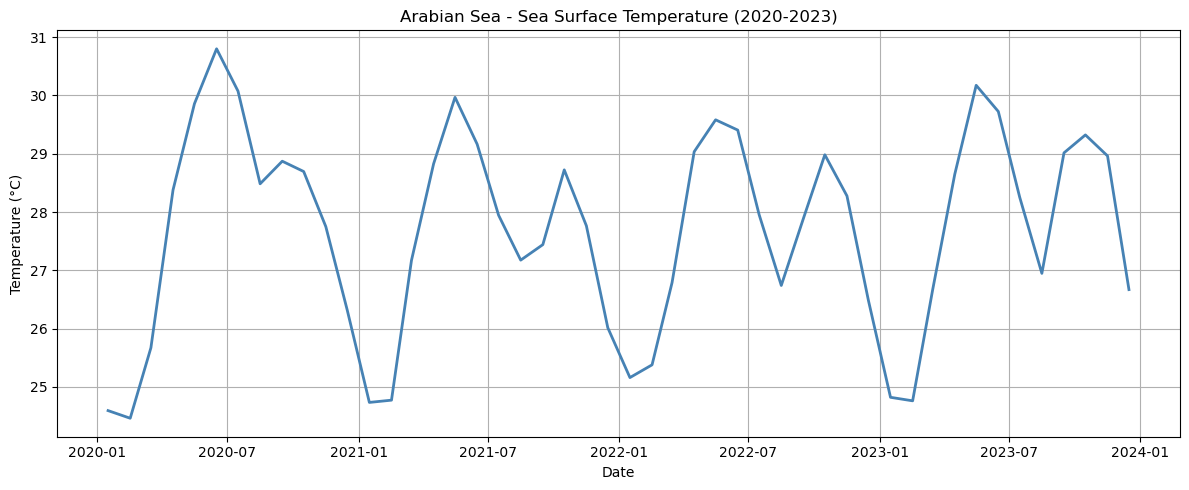

Done! Graph saved to outputs folder.


In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import io

# Using NOAA ERDDAP - dataset: jplMURSST41mday (NASA Multi-scale Ultra-high Resolution SST)
# This is one of the most reliable SST datasets on ERDDAP right now

url = (
    "https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41mday.csv?"
    "sst[(2020-01-16T00:00:00Z):1:(2023-12-16T00:00:00Z)]"
    "[(20.0):1:(20.0)][(65.0):1:(65.0)]"
)

print("Pulling data from NOAA (NASA MUR SST dataset)...")

try:
    response = requests.get(url, timeout=60)
    print(f"Status code: {response.status_code}")

    if response.status_code == 200:
        df = pd.read_csv(io.StringIO(response.text), skiprows=[1])
        df.columns = ['time', 'latitude', 'longitude', 'sst']
        df['time'] = pd.to_datetime(df['time'])
        df = df.dropna()

        print(f"Got {len(df)} data points")
        print(df.head())

        plt.figure(figsize=(12, 5))
        plt.plot(df['time'], df['sst'], color='steelblue', linewidth=2)
        plt.title('Arabian Sea - Sea Surface Temperature (2020-2023)')
        plt.xlabel('Date')
        plt.ylabel('Temperature (°C)')
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('../outputs/sst_arabian_sea.png')
        plt.show()
        print("Done! Graph saved to outputs folder.")

    else:
        print(f"Error from server: {response.text[:500]}")

except Exception as e:
    print(f"Something went wrong: {e}")
    